In [2]:
# =============================================================================
# A998 Spain 2025-26 — pull the pack-sittings (ONE query feeds all four views)
# =============================================================================
# One observation = one pack-sitting (120 s of clock). Both ages are NOMINAL
# course ages from d_students; the warehouse holds no birth date.
#
# Decision #7: the FIRST statement (statement_idx = 0) is dropped from both the
# numerator and the denominator, counting starts at the second statement, and
# everything is reported as operations PER MINUTE:
#     ops_per_min = operations(idx >= 1) / (seconds(idx >= 1) / 60)
import re, sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from databricks_connector import query

HERE = Path.cwd() if (Path.cwd() / "databricks_connector.py").exists() \
       else next(p for p in Path.cwd().rglob("databricks_connector.py")).parent
ROOT = HERE.parent
sys.path.insert(0, str(HERE))
(ROOT / "queries").mkdir(exist_ok=True); (ROOT / "plots").mkdir(exist_ok=True)

SQL      = HERE / "queries" / "a998_corrected_ops_by_age.sql"
BASE_SQL = HERE / "queries" / "a998_baseline_attempts_by_age_trimester.sql"   # source of truth
CSV = ROOT / "queries" / "a998_corrected_ops_by_age.csv"

AGE_MIN, AGE_MAX = 8, 15      # Decision #2
MIN_PER_BOX      = 100        # never draw a box from a handful of sittings

# Denominator guard (Decision #7 leaves the threshold open). A pack is a 120 s
# timed test that never runs out of operations, so a healthy sitting has ~115 s of
# counted time; a few seconds means the pupil abandoned it. Without this, one
# wrong answer in a fraction of a second becomes a rate of tens per minute --
# which is precisely how the old per-minute CSV ended up with -92 ops/min.
MIN_SECONDS = 30.0            # minimum counted time to keep a sitting
MIN_OPS     = 3               # minimum operations after dropping the first

# A998 pack reference (U Pack). A998 = multiplications and divisions only.
PACK_INFO = {14: ("multiplication", "tables 2, 5"),
             16: ("multiplication", "tables 2, 4, 5, 8"),
             20: ("multiplication", "tables 2-9"),
             32: ("division",       "tables 2, 4, 5"),
             37: ("division",       "tables 2-9"),
             39: ("both",           "tables 0-9")}
PACK_LABEL = {k: f"pack {k} — {a}, {b}" for k, (a, b) in PACK_INFO.items()}

# --- trimester windows: reuse the definition from the baseline query ---------
# Same regex as code.ipynb. The baseline .sql owns the dates; this asserts that
# our copy has not drifted from it, because a silent mismatch between two files
# would make the two notebooks disagree about what T1/T2/T3 mean.
WIN_RE = re.compile(
    r"BETWEEN DATE '(\d{4}-\d{2}-\d{2})' AND DATE '(\d{4}-\d{2}-\d{2})'\s+THEN '(T\d)'")

def windows_of(path):
    return {lab: (a, b) for a, b, lab in WIN_RE.findall(path.read_text(encoding="utf-8"))}

win_base, win_here = windows_of(BASE_SQL), windows_of(SQL)
print("Trimester windows (from a998_baseline_attempts_by_age_trimester.sql):")
for lab in sorted(win_base):
    print(f"  {lab}: {win_base[lab][0]} -> {win_base[lab][1]}")
if win_base != win_here:
    raise SystemExit(f"STOP — window drift between the two .sql files.\n"
                     f"  baseline: {win_base}\n  this query: {win_here}\n"
                     f"Edit both or neither.")
print("  -> the two .sql files agree\n")

# --- pre-flight: confirm the columns exist AND the join cannot fan out -------
# Two silent failure modes have already bitten this query: a wrong column name,
# and a LEFT JOIN that matched nothing. Both are cheap to rule out up front.
dcols = query("DESCRIBE TABLE bi_gold_prod.dwh_global_dimensions.d_students")
print("d_students columns:")
print("  " + ", ".join(dcols["col_name"]))
needed = ["student_uuid", "student_course_age", "classroom_course_age"]
gap = [c for c in needed if c not in set(dcols["col_name"])]
if gap:
    raise SystemExit(f"STOP — d_students is missing {gap}. Pick the right names above.")

fan = query("""SELECT COUNT(*) AS rows, COUNT(DISTINCT student_uuid) AS students
               FROM bi_gold_prod.dwh_global_dimensions.d_students""").iloc[0]
print(f"d_students grain: {fan['rows']:,} rows / {fan['students']:,} students"
      f" -> {'1:1, no fan-out' if fan['rows'] == fan['students'] else 'DUPLICATES: the join will multiply sittings'}")

# --- run --------------------------------------------------------------------
raw = query(SQL.read_text(encoding="utf-8").strip().rstrip(";"))
raw.to_csv(CSV, index=False)

print(f"\nA998 | ES_2025 | one row per pack-sitting, single-run only")
print(f"Rows: {len(raw):,} | CSV -> {CSV.relative_to(ROOT)}")
for c in ["student_course_age", "classroom_course_age"]:
    print(f"  {c:<22} missing {raw[c].isna().mean():6.2%}")
print(f"  first statement dropped: {int(raw['n_statements_all'].sum() - raw['n_ops'].sum()):,} "
      f"statements ({len(raw):,} sittings x 1)  [Decision #7]")
if raw["student_course_age"].isna().all():
    raise SystemExit("STOP — the d_students join matched nothing. Check the uuid "
                     "format (32 upper-case hex vs 36 lower-case with dashes).")

# --- denominator guard, before any rate is trusted --------------------------
n0 = len(raw)
too_short = raw["seconds_used"] < MIN_SECONDS
too_few   = raw["n_ops"] < MIN_OPS
print(f"\nDenominator guard: {too_short.sum():,} sittings under {MIN_SECONDS:g}s "
      f"({too_short.mean():.2%}), {too_few.sum():,} with fewer than {MIN_OPS} operations")
worst = raw.loc[too_short | too_few, "corrected_per_min"]
if len(worst):
    print(f"  rates being removed span {worst.min():.1f} to {worst.max():.1f} per minute")
raw = raw[~(too_short | too_few)]
print(f"  kept {len(raw):,} of {n0:,} sittings ({len(raw)/n0:.1%})")
print(f"  counted time now: median {raw['seconds_used'].median():.1f}s, "
      f"p05 {raw['seconds_used'].quantile(0.05):.1f}s, p95 {raw['seconds_used'].quantile(0.95):.1f}s")

# --- Decision #2, applied transparently -------------------------------------
df = raw.copy()
for c in ["student_course_age", "classroom_course_age"]:
    n = df[c].between(6, 7).sum()
    if n:
        print(f"  {c}: {n:,} sittings at age 6-7  [dropped, Decision #2]")
df = df[df["student_course_age"].between(AGE_MIN, AGE_MAX) |
        df["classroom_course_age"].between(AGE_MIN, AGE_MAX)]
for c in ["student_course_age", "classroom_course_age"]:
    df[c] = df[c].where(df[c].between(AGE_MIN, AGE_MAX))
print(f"After age filter [{AGE_MIN}-{AGE_MAX}]: {len(df):,} sittings")

# --- trimesters --------------------------------------------------------------
TRI_ORDER = ["T1", "T2", "T3"]
n_other_tri = (df["trimester"] == "other").sum()
print(f"\nSittings outside the T1/T2/T3 windows: {n_other_tri:,} "
      f"({n_other_tri / len(df):.1%}) -- dropped from the trimester plots")
df = df[df["trimester"].isin(TRI_ORDER)]
print(f"Sittings kept: {len(df):,}")
print(df.groupby("trimester").size().rename("n").to_frame().to_string())

# Decision #4 made visible: pack and trimester are largely collinear for the
# young ages (age 8: T1=pack 14, T2=16, T3=20), so a trimester comparison is only
# a within-pack comparison where the SAME pack spans several trimesters.
print("\npack x trimester (where a pack spans >1 trimester, the comparison is clean):")
ct = pd.crosstab(df["activity_pack"], df["trimester"]).reindex(columns=TRI_ORDER, fill_value=0)
print(ct.to_string())
spanning = ct.index[(ct > MIN_PER_BOX).sum(axis=1) > 1].tolist()
print(f"  -> packs present in more than one trimester: {spanning if spanning else 'none'}")

# --- do the two ages disagree? this is what justifies two panels ------------
both = df.dropna(subset=["student_course_age", "classroom_course_age"])
dis = both["student_course_age"] != both["classroom_course_age"]
print(f"\nBoth ages known: {len(both):,} | DISAGREE in {dis.mean():.2%} ({dis.sum():,})")
if dis.any():
    d = both.loc[dis, "student_course_age"] - both.loc[dis, "classroom_course_age"]
    print(f"  student minus classroom: median {d.median():+.0f} | "
          f"{(d < 0).mean():.0%} below (repeaters etc.) / {(d > 0).mean():.0%} above")
else:
    print("  -> identical everywhere: both age panels will be the same plot, and")
    print("     that is itself the finding.")

print("\nSittings per pack:")
print(df.groupby("activity_pack").size().rename("n").to_frame()
        .assign(pack=lambda t: [PACK_LABEL.get(i, "") for i in t.index]).to_string())
print(f"\ncorrected_per_min: median {df['corrected_per_min'].median():.1f}, "
      f"negative in {(df['corrected_per_min'] < 0).mean():.2%}")
print(f"correct_per_min:   median {df['correct_per_min'].median():.1f}")
print(f"n_other total {int(df['n_other'].sum()):,} "
      f"({df['n_other'].sum() / df['n_ops'].sum():.2%} of counted operations)")

Trimester windows (from a998_baseline_attempts_by_age_trimester.sql):
  T1: 2025-11-01 -> 2025-12-20
  T2: 2026-02-15 -> 2026-03-30
  T3: 2026-04-29 -> 2026-06-05
  -> the two .sql files agree

d_students columns:
  student_uuid, platform_user_id, first_name, last_name, organization_uuid, organization_name, parent_organization_name, classroom_uuid, classroom_name, avatar, language, icon, email, parents_email, home_full_access, home_training_access, digital_practice_access, home_weekly_time_limit, academic_year_id, region_id, time_zone, location_state, student_course, educational_plan_uuid, student_course_uuid, student_course_age, classroom_course_age, bubble_plan_uuid, is_rti, is_spark, individual_access, created_at, updated_at, dbt_loaded_at
d_students grain: 498,343 rows / 498,343 students -> 1:1, no fan-out

A998 | ES_2025 | one row per pack-sitting, single-run only
Rows: 396,988 | CSV -> queries\a998_corrected_ops_by_age.csv
  student_course_age     missing  0.16%
  classroom_cours

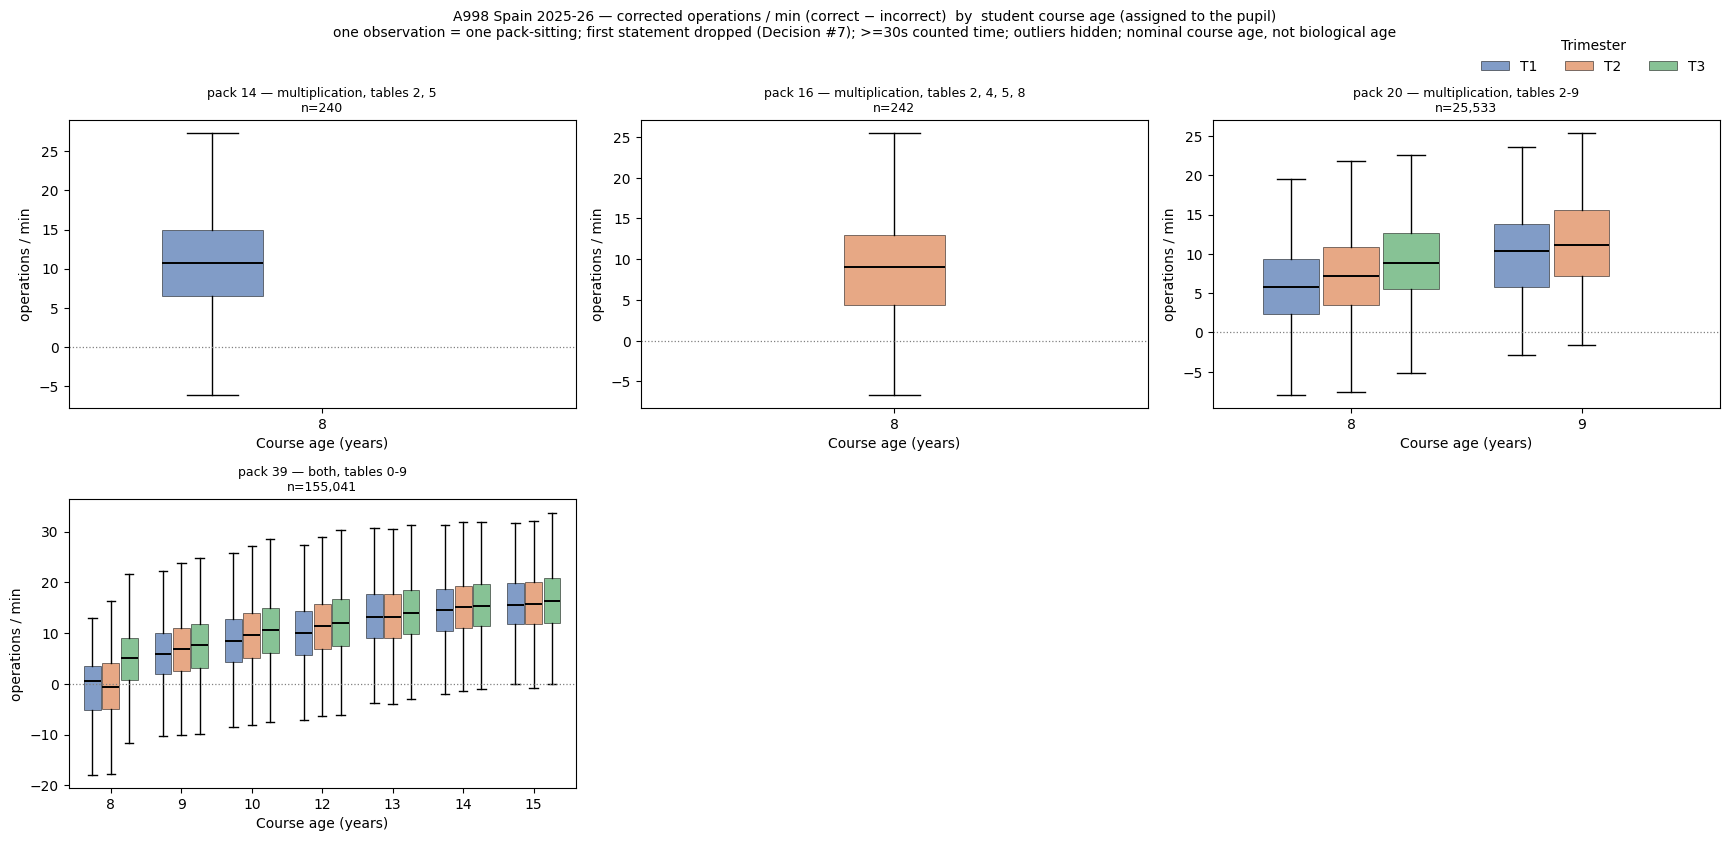

plot -> plots\a998_es2025_boxplot_corrected_per_min_by_student_course_age_by_trimester.png


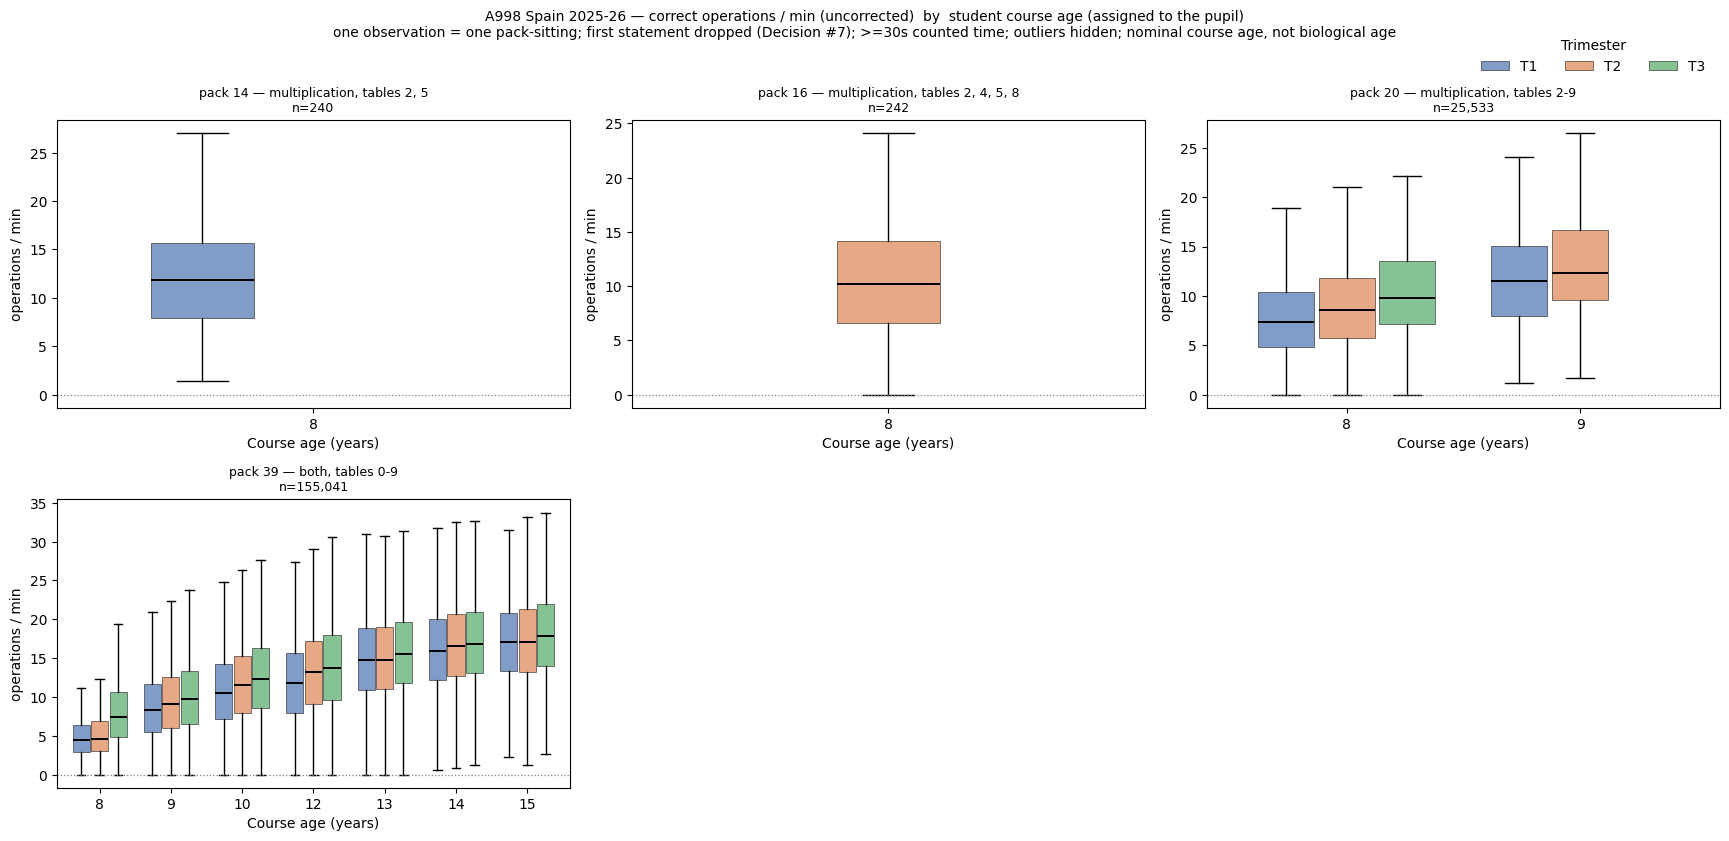

plot -> plots\a998_es2025_boxplot_correct_per_min_by_student_course_age_by_trimester.png


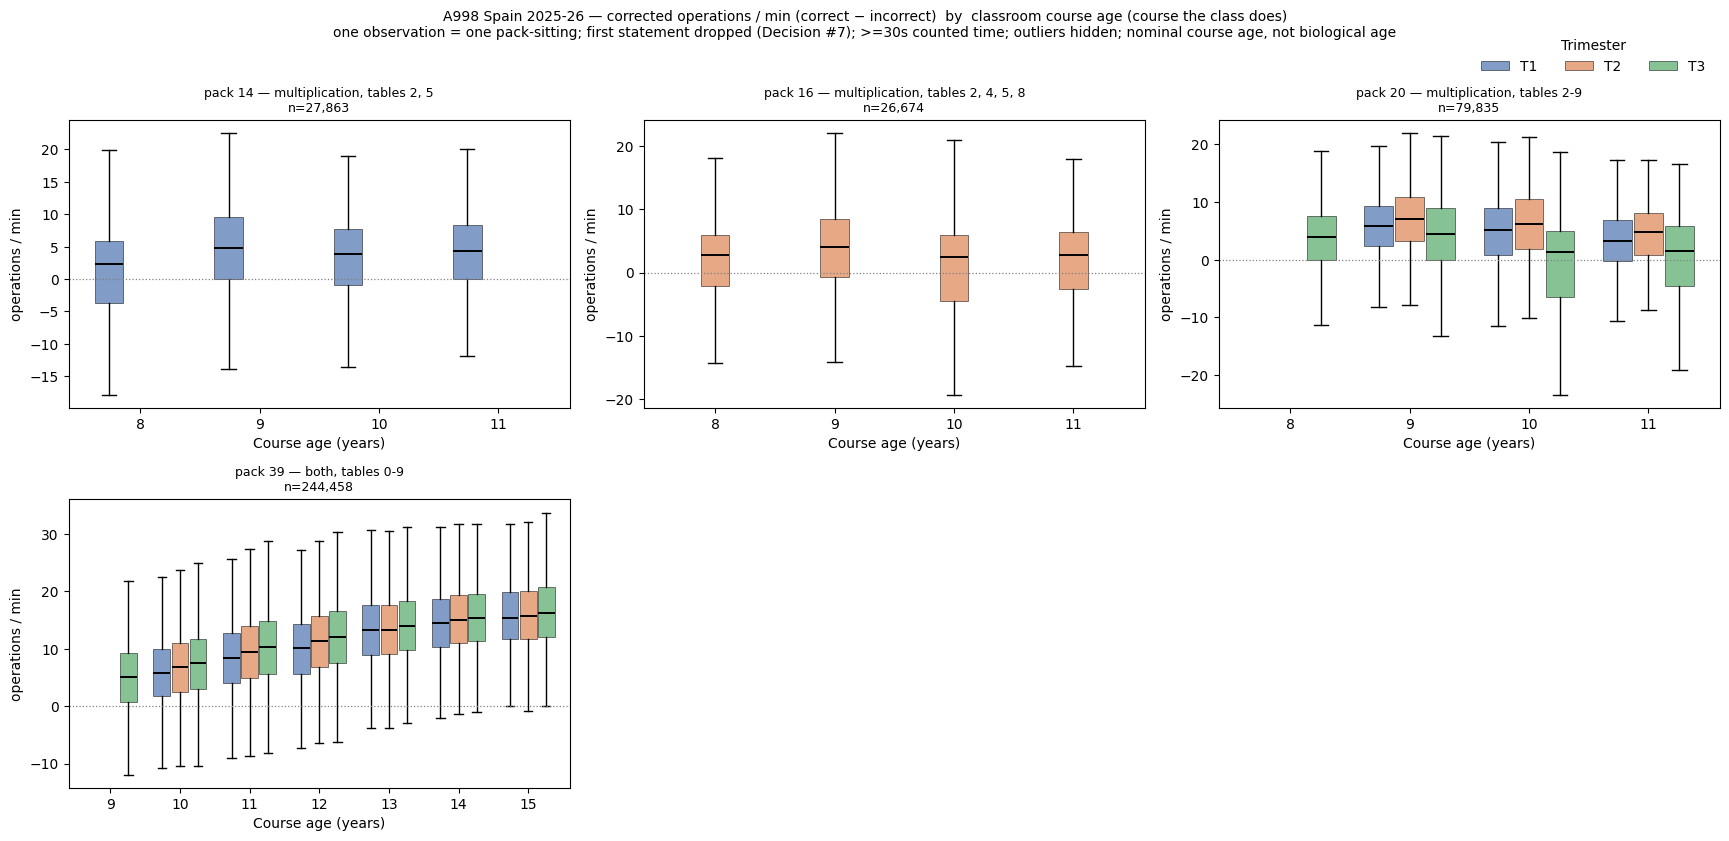

plot -> plots\a998_es2025_boxplot_corrected_per_min_by_classroom_course_age_by_trimester.png


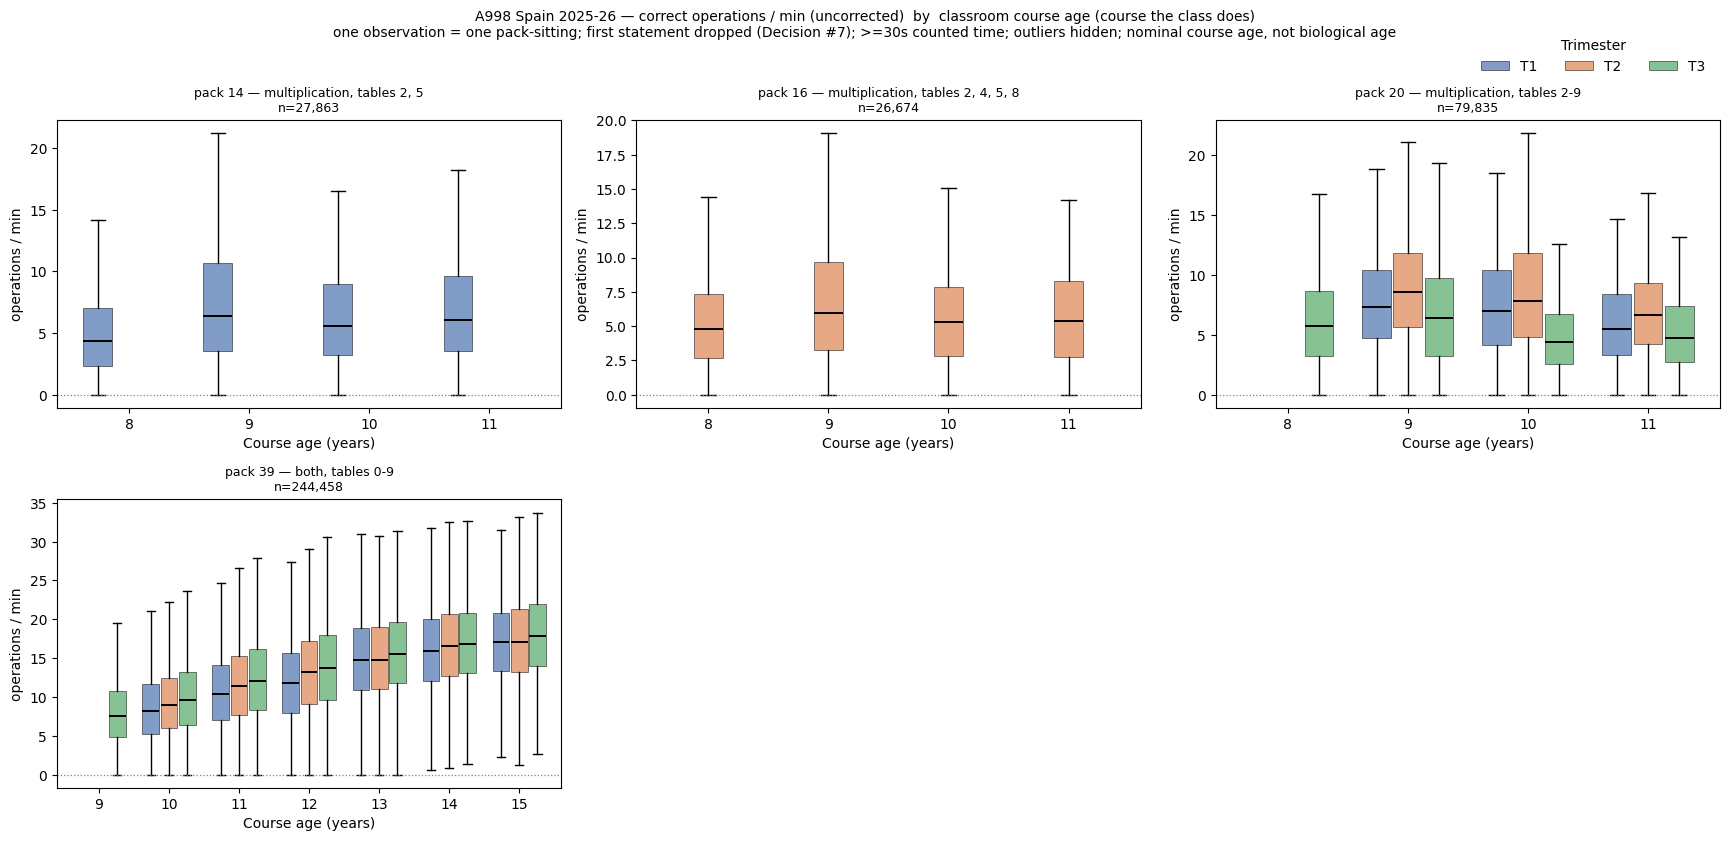

plot -> plots\a998_es2025_boxplot_correct_per_min_by_classroom_course_age_by_trimester.png

Median operations/min by age x trimester, all four variants:

  corrected_per_min / student_course_age
trimester             T1    T2    T3
student_course_age                  
8.0                  5.8   7.1   5.1
9.0                  6.0   6.9   7.6
10.0                 8.5   9.6  10.5
11.0                14.7  17.9  15.1
12.0                10.1  11.4  12.1
13.0                13.2  13.2  14.0
14.0                14.6  15.1  15.3
15.0                15.4  15.8  16.3

  correct_per_min / student_course_age
trimester             T1    T2    T3
student_course_age                  
8.0                  7.3   8.5   7.5
9.0                  8.4   9.1   9.7
10.0                10.5  11.6  12.3
11.0                15.2  18.6  16.1
12.0                11.8  13.2  13.8
13.0                14.8  14.8  15.6
14.0                15.9  16.5  16.8
15.0                17.0  17.1  17.8

  corrected_per_min / cl

In [3]:
# =============================================================================
# The four boxplots: {student age, classroom age} x {corrected, raw correct}
# split by TRIMESTER within each age
# =============================================================================
# One panel per pack (pack difficulty differs enormously: pack 14 = tables 2 and 5;
# pack 39 = tables 0-9 with multiplications AND divisions), so comparing ages
# across packs would confound difficulty with age -- Decision #4.
# Within a panel: x = course age, and one box per trimester side by side.

AGE_COLS = {"student_course_age":   "student course age (assigned to the pupil)",
            "classroom_course_age": "classroom course age (course the class does)"}
# Decision #7: always per minute
VAL_COLS = {"corrected_per_min": "corrected operations / min (correct − incorrect)",
            "correct_per_min":   "correct operations / min (uncorrected)"}
TRI_COLOR = {"T1": "#4C72B0", "T2": "#DD8452", "T3": "#55A868"}

def plot_variant(age_col, val_col):
    d = df.dropna(subset=[age_col])
    if d.empty:
        raise ValueError(f"{age_col} is missing for every sitting")
    packs = [p for p in sorted(d["activity_pack"].unique())
             if len(d[d["activity_pack"] == p]) >= MIN_PER_BOX]
    if not packs:
        raise ValueError(f"{age_col}: {len(d):,} rows but no pack reaches "
                         f"MIN_PER_BOX={MIN_PER_BOX}")
    ncol = min(3, len(packs)); nrow = int(np.ceil(len(packs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.8 * ncol, 4.1 * nrow), squeeze=False)

    for ax, p in zip(axes.ravel(), packs):
        dp = d[d["activity_pack"] == p]
        ages = sorted(a for a in dp[age_col].unique()
                      if (dp[age_col] == a).sum() >= MIN_PER_BOX)
        if not ages:
            ax.axis("off"); continue
        w = 0.24
        for j, t in enumerate(TRI_ORDER):
            data, pos = [], []
            for i, a in enumerate(ages):
                v = dp.loc[(dp[age_col] == a) & (dp["trimester"] == t), val_col]
                if len(v) >= MIN_PER_BOX:
                    data.append(v.values); pos.append(i + (j - 1) * (w + 0.02))
            if not data:
                continue
            bp = ax.boxplot(data, positions=pos, widths=w, showfliers=False,
                            patch_artist=True, manage_ticks=False)
            for b in bp["boxes"]:
                b.set(facecolor=TRI_COLOR[t], alpha=0.7, edgecolor="black", linewidth=0.5)
            for m in bp["medians"]:
                m.set(color="black", linewidth=1.4)
        ax.axhline(0, ls=":", lw=0.9, color="grey")
        ax.set_xticks(range(len(ages)))
        ax.set_xticklabels([f"{int(a)}" for a in ages])
        ax.set_xlim(-0.6, len(ages) - 0.4)
        ax.set_title(f"{PACK_LABEL.get(p, f'pack {p}')}\nn={len(dp):,}", fontsize=9)
        ax.set_xlabel("Course age (years)")
        ax.set_ylabel("operations / min")

    for ax in axes.ravel()[len(packs):]:
        ax.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=TRI_COLOR[t], alpha=0.7,
                             edgecolor="black", linewidth=0.5) for t in TRI_ORDER]
    fig.legend(handles, TRI_ORDER, title="Trimester", loc="upper right",
               ncol=3, frameon=False, bbox_to_anchor=(0.99, 1.0))
    fig.suptitle(f"A998 Spain 2025-26 — {VAL_COLS[val_col]}  by  {AGE_COLS[age_col]}\n"
                 f"one observation = one pack-sitting; first statement dropped "
                 f"(Decision #7); >={MIN_SECONDS:g}s counted time; outliers hidden; "
                 f"nominal course age, not biological age", y=1.02, fontsize=10)
    fig.tight_layout()
    out = ROOT / "plots" / f"a998_es2025_boxplot_{val_col}_by_{age_col}_by_trimester.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"plot -> {out.relative_to(ROOT)}")

for age_col in AGE_COLS:
    for val_col in VAL_COLS:
        try:
            plot_variant(age_col, val_col)
        except ValueError as e:
            print(f"SKIPPED {val_col} by {age_col}: {e}")

# --- medians by age AND trimester -------------------------------------------
print("\nMedian operations/min by age x trimester, all four variants:")
for a in AGE_COLS:
    for v in VAL_COLS:
        piv = (df.dropna(subset=[a]).pivot_table(index=a, columns="trimester",
                                                 values=v, aggfunc="median")
                 .reindex(columns=TRI_ORDER))
        print(f"\n  {v} / {a}")
        print(piv.round(1).to_string())


Students | pack 39 (pack 39 — both, tables 0-9) | ES_2025 | trimesters POOLED
  244,429 pack-sittings | ages 9-15
                          n  median
classroom_course_age               
9.0                   23564     5.0
10.0                  77050     6.6
11.0                  75960     9.3
12.0                  28265    11.1
13.0                  24831    13.5
14.0                  11643    15.0
15.0                   3116    15.8

  trimester mix per age (pooled into one distribution per age):
trimester                T1     T2     T3
classroom_course_age                     
9.0                      30     26  23508
10.0                  27120  25949  23981
11.0                  27858  26133  21969
12.0                  10693   8444   9128
13.0                   9766   7133   7932
14.0                   4682   3564   3397
15.0                   1639    805    672

Innovamat Learning Team | queries/learning_team_per_min.csv | 17 people
  median 24.7 ops/min (range 5.5-33.4)
  NOTE:

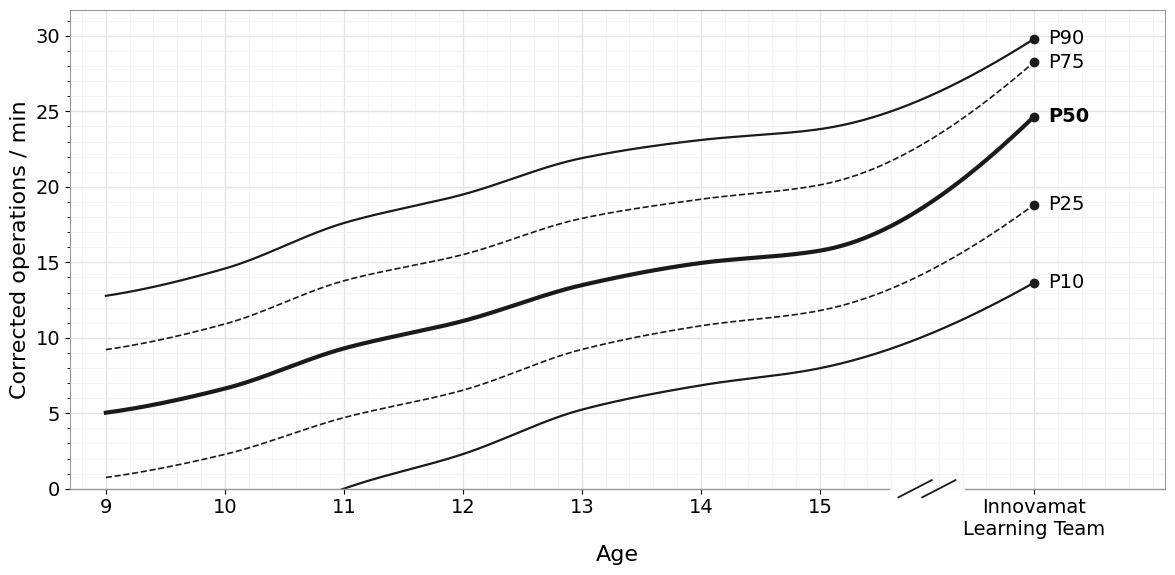


plot -> plots\a998_es2025_pack39_percentile_curves_adult.png
Data: A998, ES_2025, pack 39, all trimesters pooled, classroom_course_age,
      corrected = correct − incorrect, per minute, Decision #7 (first
      statement dropped), >=30s counted time, >=3 operations.
      Adult node read from queries/learning_team_per_min.csv.
P50 by age: 9:5.0, 10:6.6, 11:9.3, 12:11.1, 13:13.5, 14:15.0, 15:15.8 | adult 24.7


In [5]:
# =============================================================================
# Orbegozo-style percentile curves — pack 39, by classroom_course_age,
# all trimesters pooled, with the Innovamat Learning Team reference on the right
# =============================================================================
# Aesthetic and adult reference exactly as F2.ipynb cell 6: the team's rates are
# READ FROM queries/learning_team_per_min.csv, not recomputed from the warehouse.
from scipy.interpolate import PchipInterpolator

PACK    = 39
AGE_COL = "classroom_course_age"
VAL_COL = "corrected_per_min"
pcts    = [10, 25, 50, 75, 90]
style   = {10: (1.6, "-"), 90: (1.6, "-"), 50: (3.0, "-"), 25: (1.2, "--"), 75: (1.2, "--")}

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["font.size"] = 15

# ---------- students: pack 39, trimesters pooled ----------------------------
# `df` already carries Decision #2 (ages 8-15), the denominator guard and the
# trimester filter from the pull cell.
s39 = df[df["activity_pack"] == PACK].dropna(subset=[AGE_COL])
ages = np.array(sorted(a for a in s39[AGE_COL].unique()
                       if (s39[AGE_COL] == a).sum() >= MIN_PER_BOX))
s39 = s39[s39[AGE_COL].isin(ages)]

print(f"Students | pack {PACK} ({PACK_LABEL[PACK]}) | ES_2025 | trimesters POOLED")
print(f"  {len(s39):,} pack-sittings | ages {ages.min():.0f}-{ages.max():.0f}")
print(s39.groupby(AGE_COL).agg(n=(VAL_COL, "size"), median=(VAL_COL, "median")).round(1).to_string())
print("\n  trimester mix per age (pooled into one distribution per age):")
print(pd.crosstab(s39[AGE_COL], s39["trimester"]).to_string())

table = (s39.groupby(AGE_COL)[VAL_COL]
            .apply(lambda x: np.percentile(x, pcts)).reindex(ages))
P = {p: np.array([table.loc[a][i] for a in ages]) for i, p in enumerate(pcts)}

# ---------- adult reference: straight from the CSV --------------------------
lt = pd.read_csv(ROOT / "queries" / "learning_team_per_min.csv")
lt.columns = [c.strip().lstrip("﻿") for c in lt.columns]
adult = {p: np.percentile(lt[VAL_COL], p) for p in pcts}
x_adult = ages.max() + 1.8

print(f"\nInnovamat Learning Team | queries/learning_team_per_min.csv | {len(lt)} people")
print(f"  median {lt[VAL_COL].median():.1f} ops/min "
      f"(range {lt[VAL_COL].min():.1f}-{lt[VAL_COL].max():.1f})")
print("  NOTE: these rates come with the CSV's own method (whole session, first")
print("  statement included), so the adult node is an indicative benchmark rather")
print("  than a like-for-like extension of the pupil curves.")

# ---------- smooth across the whole span so curves flow into the adult node --
ages_ext = np.append(ages, x_adult)
grid = np.linspace(ages.min(), x_adult, 400)
Psm = {p: PchipInterpolator(ages_ext, np.append(P[p], adult[p]))(grid) for p in pcts}

fig, ax = plt.subplots(figsize=(12, 6.8))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

for p in pcts:
    lw, ls = style[p]
    ax.plot(grid, Psm[p], color="#1a1a1a", linewidth=lw, linestyle=ls)
    ax.plot(x_adult, adult[p], "o", color="#1a1a1a", markersize=6)
    ax.text(x_adult + 0.12, adult[p], f"P{p}", va="center", ha="left",
            fontsize=14, fontweight="bold" if p == 50 else "normal")

ax.set_xticks(list(ages) + [x_adult])
ax.set_xticklabels([f"{a:.0f}" for a in ages] + ["Innovamat\nLearning Team"])
ax.tick_params(axis="both", labelsize=14)
ax.grid(which="major", color="#E5E5E5", linewidth=1.0)
ax.minorticks_on(); ax.grid(which="minor", color="#F2F2F2", linewidth=0.6)
ax.tick_params(which="minor", bottom=False)

xlo, xhi = ages.min() - 0.3, x_adult + 1.9      # room for the P10..P90 labels
ax.set_xlim(xlo, xhi)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)         # a little headroom on top
for sp in ax.spines.values():
    sp.set_color("#999999")

# --- break the BOTTOM spine only, with the // marks -------------------------
x_break = ages.max() + 0.9
half = 0.32
trans = ax.get_xaxis_transform()
ax.spines["bottom"].set_visible(False)
ax.plot([xlo, x_break - half], [0, 0], transform=trans, color="#999999", lw=1.0, clip_on=False)
ax.plot([x_break + half, xhi], [0, 0], transform=trans, color="#999999", lw=1.0, clip_on=False)
dx, dy, gap = 0.14, 0.018, 0.10
for off in (-gap, gap):
    ax.plot([x_break + off - dx, x_break + off + dx], [-dy, dy],
            transform=trans, color="#1a1a1a", lw=1.3, clip_on=False, zorder=5)

ax.set_xlabel("Age", fontsize=16)
ax.set_ylabel("Corrected operations / min", fontsize=16)

# tight_layout() would clip the '//' marks (drawn with clip_on=False below the
# axis) and the two-line "Innovamat / Learning Team" tick label, so the margins
# are reserved by hand instead.
fig.subplots_adjust(left=0.085, right=0.93, bottom=0.24, top=0.95)

out = ROOT / "plots" / f"a998_es2025_pack{PACK}_percentile_curves_adult.png"
plt.savefig(out, dpi=600, bbox_inches="tight", pad_inches=0.3)
plt.savefig(out.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.3)
plt.show()

print(f"\nplot -> {out.relative_to(ROOT)}")
print(f"Data: A998, ES_2025, pack {PACK}, all trimesters pooled, {AGE_COL},")
print(f"      corrected = correct − incorrect, per minute, Decision #7 (first")
print(f"      statement dropped), >={MIN_SECONDS:g}s counted time, >={MIN_OPS} operations.")
print(f"      Adult node read from queries/learning_team_per_min.csv.")
print("P50 by age: " + ", ".join(f"{a:.0f}:{v:.1f}" for a, v in zip(ages, P[50])) +
      f" | adult {adult[50]:.1f}")

**Remember:** this is for pack 39, corrected operations, omitting first statement, only Spain 2025